#Data 620-Project02: Two-Mode Network Analysis of Facebook-like Forum Communication Data

Group member: Mahmud Hasan Al Raji and Warner Alexis

#Assignment details

1. Identify a large 2-node network dataset—you can start with a dataset in a repository.  Your data should meet the criteria that it consists of ties between and not within two (or more) distinct groups.

2. Reduce the size of the network using a method such as the island method described in chapter 4 of social network analysis.

3. What can you infer about each of the distinct groups?


#Introduction:

In this project, the Facebook-like Forum Network dataset is used. The dataset was attained from the same online community as the online social network and is now available at toreopsahl.com (link: https://toreopsahl.com/datasets). The dataset, “Weighted static two-mode network (weighted by number of messages)”, represents interactions between users and topics in that a weight is assigned to the ties based on the number of messages that a user posted to a topic in an online forum. Each tie basically shows how many messages a user posted in a specific topic. This makes it a suitable two-mode network for analysis because it captures relationships between two distinct groups (users and threads) rather than within them.


#Import libraries



In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from networkx.algorithms import bipartite

#Load dataset

In [2]:
# Load the Tore Opsahl weighted static two-mode network dataset
# It is the Facebook-like Forum Network that was attained from the same online community as the online social network

# Get GitHub raw URL
url = "https://raw.githubusercontent.com/Raji030/data620_Pr02/refs/heads/main/OF_two-mode_weightedmsg.txt"

# Load the dataset
df = pd.read_csv(url, sep=" ", header=None)
df.columns = ["user", "thread", "weight"]


#Check dataset

In [3]:
#See first few rows of the dataset
print(df.head())

print("\nSummary:")
print("Number of users:", df['user'].nunique())
print("Number of threads:", df['thread'].nunique())
print("Number of edges:", len(df))

   user  thread  weight
0     1       1       1
1     1      39       9
2     1     102       2
3     1     154       1
4     1     357       5

Summary:
Number of users: 899
Number of threads: 522
Number of edges: 7089


#Create a weighted bipartite network

In [5]:
# Define the graph
B = nx.Graph()
# Add nodes with bipartite attribute
B.add_nodes_from(df['user'].unique(), bipartite=0)   # Users
B.add_nodes_from(df['thread'].unique(), bipartite=1) # Threads

# Add weighted edges
for idx, row in df.iterrows():
    B.add_edge(row['user'], row['thread'], weight=row['weight'])

print("\nBipartite network created:")
print("Number of nodes:", B.number_of_nodes())
print("Number of edges:", B.number_of_edges())


Bipartite network created:
Number of nodes: 899
Number of edges: 7046


#Check basic network properties

In [8]:
density = nx.density(B)
print(f"Network Density: {density:.4f}")

components = nx.number_connected_components(B)
print("Number of Connected Components:", components)


Network Density: 0.0175
Number of Connected Components: 1


The density of 1.75% means that the network is sparse i.e. 1.75% of all possible user-thread connections actually exist here. So, the users are selective here and post in only a small number of threads, rather than interacting with every possible thread. The LCC of 1 means the entire network forms one single connected structure, with no separate clusters, sub-groups, or isolated nodes. Every user and thread is connected either directly or indirectly within this one big network.

#Reduction of the bipartite network using island method
#Step 1: Define the trim_edges() function

This function “raises the water level”, meaning it keeps only edges with weight > threshold and returns a new reduced graph (non-destructive).

In [7]:
#import networkx as nx

def trim_edges(g, weight=1):
    """
    Virtually raises the water level.
    Returns a new subgraph containing only edges
    with weight > given threshold.
    """
    g2 = nx.Graph()
    for f, to, edata in g.edges(data=True):
        if edata['weight'] > weight:
            g2.add_edge(f, to, **edata)
    return g2


#Step 2: Define the island_method() function

This island_method() function calculates the min and max edge weights, divides that range into steps (iterations), and returns a list of graphs. Each graph corresponds to one “water level.”

In [8]:
def island_method(g, iterations=5):
    """
    Generates subnetworks for different water levels (edge weight thresholds).
    Returns a list of [threshold, subgraph] pairs.
    """
    weights = [edata['weight'] for f, to, edata in g.edges(data=True)]
    mn = int(min(weights))
    mx = int(max(weights))

    # Step size so that we have roughly `iterations` number of thresholds
    step = int((mx - mn) / iterations) if iterations > 0 else 1

    # Return list of [threshold, subgraph]
    return [[threshold, trim_edges(g, threshold)] for threshold in range(mn, mx, step)]


#Step 3: Apply the island method to the bipartite network

In [9]:
# Apply to the bipartite network B
islands = island_method(B, iterations=6)  # You can adjust iterations

# Print summary information for each water level
for threshold, subg in islands:
    print(f"\nThreshold ≥ {threshold}")
    print("Number of nodes:", subg.number_of_nodes())
    print("Number of edges:", subg.number_of_edges())
    print("Number of connected components:", nx.number_connected_components(subg))



Threshold ≥ 1
Number of nodes: 761
Number of edges: 4306
Number of connected components: 1

Threshold ≥ 29
Number of nodes: 103
Number of edges: 113
Number of connected components: 10

Threshold ≥ 57
Number of nodes: 31
Number of edges: 26
Number of connected components: 5

Threshold ≥ 85
Number of nodes: 14
Number of edges: 8
Number of connected components: 6

Threshold ≥ 113
Number of nodes: 5
Number of edges: 3
Number of connected components: 2

Threshold ≥ 141
Number of nodes: 4
Number of edges: 2
Number of connected components: 2

Threshold ≥ 169
Number of nodes: 2
Number of edges: 1
Number of connected components: 1


We applied the island method to the bipartite user–thread network. Several thresholds were tested to remove weaker connections. At low thresholds, the network remained large and dense. At very high thresholds, only a few nodes and edges remained.So, we chose 57 as the threshold because it reduced weak connections while preserving meaningful clusters. At this level, the network had 31 nodes, 26 edges, and formed 5 separate groups or islands.

Each of the 5 groups or islands represents users who interacted frequently in specific threads. These groups indicate strong engagement and shared interest around certain discussion topics. The separation into distinct islands shows that the community naturally formed smaller active clusters. Weaker or casual interactions were removed, leaving only the core structure of the most active users and threads.

#Define the reduced bipartie network using the selected threshold

In [10]:
# Threshoild got from island method
threshold = 57

# Create a reduced graph only with edges above threshold
edges_above_threshold = [(u, v, edata) for u, v, edata in B.edges(data=True) if edata['weight'] >= threshold]

# Build the trimmed network only from those edges
B_trimmed = nx.Graph()
B_trimmed.add_edges_from([(u, v, edata) for u, v, edata in edges_above_threshold])

print(f"Reduced network at threshold ≥ {threshold}")
print("Number of nodes:", B_trimmed.number_of_nodes())
print("Number of edges:", B_trimmed.number_of_edges())
print("Number of connected components:", nx.number_connected_components(B_trimmed))



Reduced network at threshold ≥ 57
Number of nodes: 31
Number of edges: 26
Number of connected components: 5


In [11]:
##Identify users and htreads
#Re-add bipartite attributes from the original graph
for n, d in B.nodes(data=True):
    if n in B_trimmed:
        B_trimmed.nodes[n]['bipartite'] = d['bipartite']

#Identify bipartite sets
users = [n for n, d in B_trimmed.nodes(data=True) if d['bipartite'] == 0]
threads = [n for n, d in B_trimmed.nodes(data=True) if d['bipartite'] == 1]



#Visualizations for reduced ibpartite network

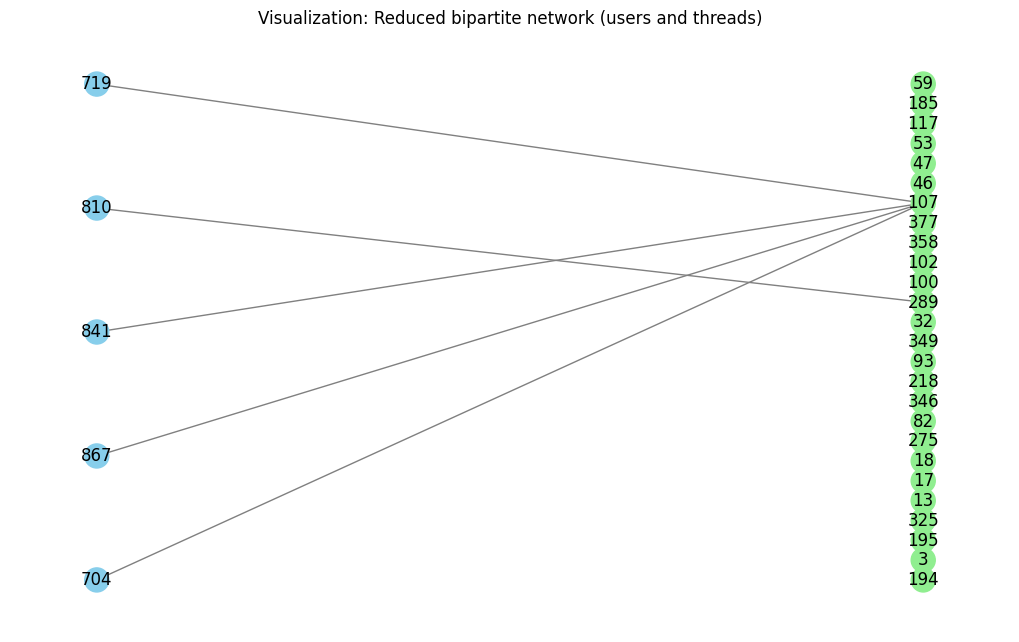

In [12]:
##Basic bipartite layout
plt.figure(figsize=(10,6))
pos = nx.bipartite_layout(B_trimmed, users)
nx.draw(B_trimmed, pos, with_labels=True,
        node_color=['skyblue' if n in users else 'lightgreen' for n in B_trimmed.nodes()],
        node_size=300, edge_color='gray')
plt.title("Visualization: Reduced bipartite network (users and threads)")
plt.show()


This plot shows the simplified bipartite network structure after applying the threshold of 57. The blue nodes represent users, and the green nodes represent threads. Only strong connections are retained, showing the core active interactions between users and threads.

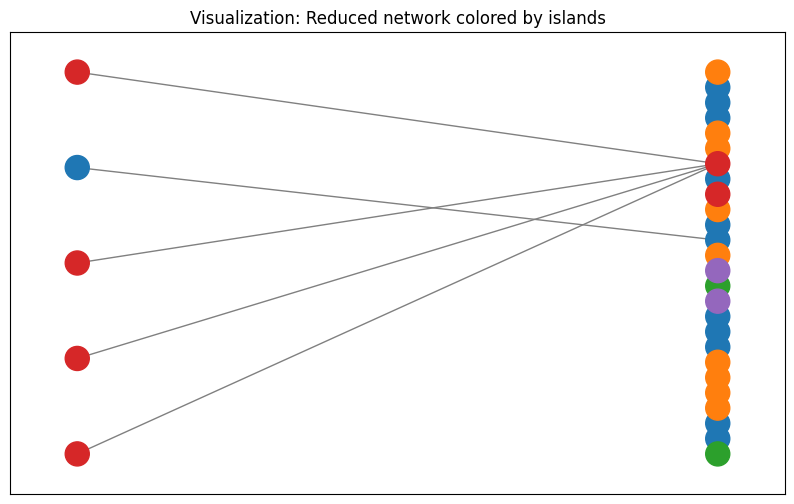

In [13]:
##Color-coded islands
components = list(nx.connected_components(B_trimmed))
colors = cm.tab10.colors  # up to 10 distinct colors

plt.figure(figsize=(10,6))
for i, comp in enumerate(components):
    nx.draw_networkx_nodes(B_trimmed, pos, nodelist=comp,
                           node_color=[colors[i % 10]]*len(comp), node_size=300)
nx.draw_networkx_edges(B_trimmed, pos, edge_color='gray')
plt.title("Visualization: Reduced network colored by islands")
plt.show()

This visualization colors each connected component or island differently.
The five color groups represent five distinct clusters of strong user–thread interactions.
Each cluster shows users engaging with a specific subset of threads, revealing focused participation patterns.

Top 5 nodes by degree:
100: 5
107: 5
117: 4
13: 3
59: 3


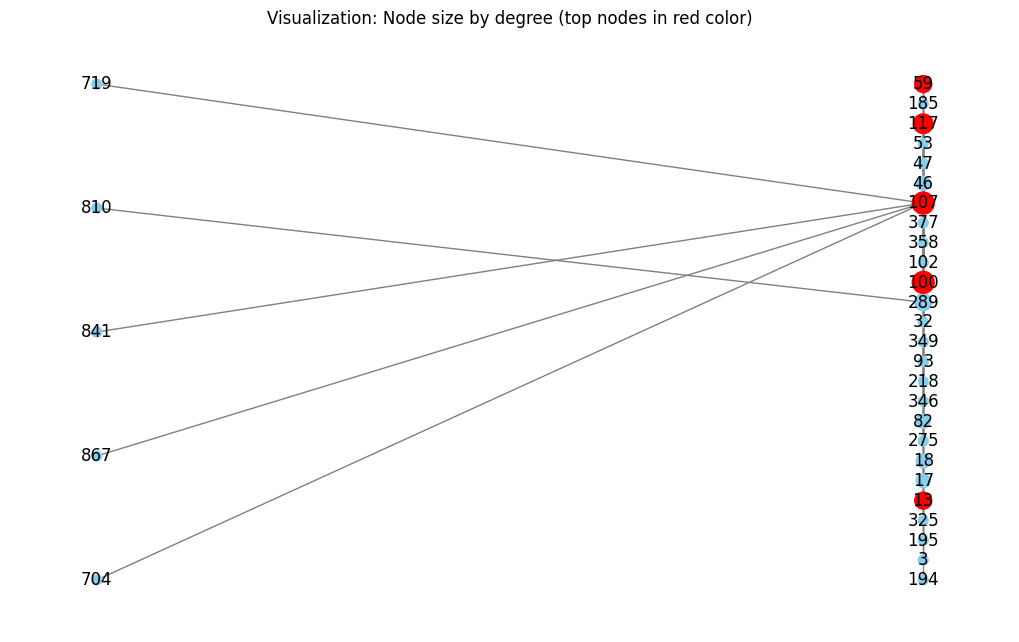

In [14]:
# Compute node degrees
degree_dict = dict(B_trimmed.degree())

# Sort nodes by degree (descending order)
sorted_degrees = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)

# Identify top 5 high degree nodes
top_nodes = [node for node, deg in sorted_degrees[:5]]

# Print info
print("Top 5 nodes by degree:")
for node, deg in sorted_degrees[:5]:
    print(f"{node}: {deg}")

# Define node colors: red for top nodes, skyblue for others
node_colors = ["red" if n in top_nodes else "skyblue" for n in B_trimmed.nodes()]

# Node sizes proportional to degree
node_sizes = [degree_dict[n]*50 for n in B_trimmed.nodes()]

# Draw the network
plt.figure(figsize=(10,6))
nx.draw(B_trimmed, pos, with_labels=True,
        node_color=node_colors, node_size=node_sizes, edge_color='gray')

plt.title("Visualization: Node size by degree (top nodes in red color)")
plt.show()


Here, node size reflects its degree (number of strong connections). Larger nodes indicate key users or threads that are highly connected within the reduced network. This helps identify central participants or topics among the most active interactions.

#Project bipartite network to one-mode networks

In [15]:

# Identify user and thread nodes in the reduced network
users_trimmed = [n for n, d in B_trimmed.nodes(data=True) if d.get('bipartite') == 0]
threads_trimmed = [n for n, d in B_trimmed.nodes(data=True) if d.get('bipartite') == 1]

# Make sure they match node names (convert all to strings if needed)
B_trimmed = nx.relabel_nodes(B_trimmed, {n: str(n) for n in B_trimmed.nodes()})

# Re-identify nodes (after relabeling)
users_trimmed = [n for n, d in B_trimmed.nodes(data=True) if d.get('bipartite') == 0]
threads_trimmed = [n for n, d in B_trimmed.nodes(data=True) if d.get('bipartite') == 1]

# Create projections
user_proj_trimmed = bipartite.weighted_projected_graph(B_trimmed, users_trimmed)
thread_proj_trimmed = bipartite.weighted_projected_graph(B_trimmed, threads_trimmed)

print("User–suer projected network:")
print("User-user projection nodes:", len(user_proj_trimmed.nodes()))
print("User-user projection edges:", len(user_proj_trimmed.edges()))

print("\nThread–thread projected network:")
print("Thread-thread projection nodes:", len(thread_proj_trimmed.nodes()))
print("Thread-thread projection edges:", len(thread_proj_trimmed.edges()))


User–suer projected network:
User-user projection nodes: 8
User-user projection edges: 12

Thread–thread projected network:
Thread-thread projection nodes: 31
Thread-thread projection edges: 33


#User–user projection analysis

In [16]:
import networkx as nx
from networkx.algorithms import community

# Degree centrality
user_degree = nx.degree_centrality(user_proj_trimmed)

# Betweenness centrality
user_betweenness = nx.betweenness_centrality(user_proj_trimmed, weight='weight')

# Create dataFrame for users
user_centrality_df = pd.DataFrame({
    'Node': list(user_proj_trimmed.nodes()),
    'Degree centrality': [user_degree[n] for n in user_proj_trimmed.nodes()],
    'Betweenness centrality': [user_betweenness[n] for n in user_proj_trimmed.nodes()]
})

# Sort by edgree centrality descending
user_centrality_df = user_centrality_df.sort_values(by='Degree centrality', ascending=False).reset_index(drop=True)

print("User–user centralities:")
#display(user_centrality_df)
print(user_centrality_df.to_string(index=True))

# Community detection using greedy modularity
user_communities = community.greedy_modularity_communities(user_proj_trimmed)
print("\nUser Communities:")
for i, comm in enumerate(user_communities):
    print(f"Community {i+1}: {comm}")


User–user centralities:
  Node  Degree centrality  Betweenness centrality
0  704           0.571429                0.000000
1  719           0.571429                0.000000
2  841           0.571429                0.000000
3  867           0.571429                0.000000
4  358           0.571429                0.000000
5  810           0.285714                0.047619
6   53           0.142857                0.000000
7  100           0.142857                0.000000

User Communities:
Community 1: frozenset({'841', '358', '704', '719', '867'})
Community 2: frozenset({'810', '53', '100'})


#Thread–thread projection analysis

In [17]:
# Degree centrality
thread_degree = nx.degree_centrality(thread_proj_trimmed)

# Betweenness centrality
thread_betweenness = nx.betweenness_centrality(thread_proj_trimmed, weight='weight')

# Create dataFrame for threads
thread_centrality_df = pd.DataFrame({
    'Node': list(thread_proj_trimmed.nodes()),
    'Degree centrality': [thread_degree[n] for n in thread_proj_trimmed.nodes()],
    'Betweenness centrality': [thread_betweenness[n] for n in thread_proj_trimmed.nodes()]
})

# Sort by degree centrality descending
thread_centrality_df = thread_centrality_df.sort_values(by='Degree centrality', ascending=False).reset_index(drop=True)

print("Thread–thread centralities:")
#display(thread_centrality_df)
print(thread_centrality_df.to_string(index=True))

# Community detection
thread_communities = community.greedy_modularity_communities(thread_proj_trimmed)
print("\nThread Communities:")
for i, comm in enumerate(thread_communities):
    print(f"Community {i+1}: {comm}")

Thread–thread centralities:
   Node  Degree centrality  Betweenness centrality
0   100           0.200000                0.025287
1    18           0.133333                0.013793
2   117           0.133333                0.000000
3   289           0.133333                0.000000
4    82           0.133333                0.000000
5   377           0.133333                0.000000
6   185           0.133333                0.000000
7   358           0.133333                0.013793
8   275           0.100000                0.000000
9    17           0.100000                0.009195
10  346           0.100000                0.000000
11    3           0.100000                0.000000
12   47           0.066667                0.000000
13   13           0.066667                0.002299
14  325           0.066667                0.000000
15   53           0.066667                0.000000
16  810           0.066667                0.000000
17  102           0.066667                0.000000
18 

#Visualize the one-mode projections

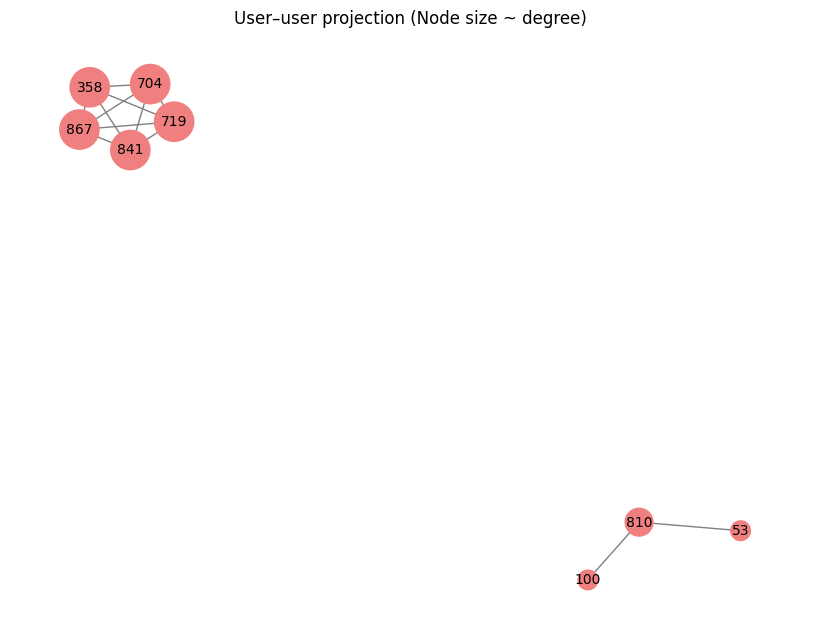

In [18]:
#user-user plot layout
plt.figure(figsize=(8, 6))

# Node size proportional to degree
degree_dict = dict(user_proj_trimmed.degree())
node_sizes = [degree_dict[n]*200 for n in user_proj_trimmed.nodes()]  # scale factor for visibility

# Use spring layout for better spacing
pos = nx.spring_layout(user_proj_trimmed, seed=42)

# Draw network
nx.draw(
    user_proj_trimmed,
    pos,
    with_labels=True,
    node_color="lightcoral",
    edge_color="gray",
    node_size=node_sizes,
    font_size=10
)

plt.title("User–user projection (Node size ~ degree)")
plt.show()



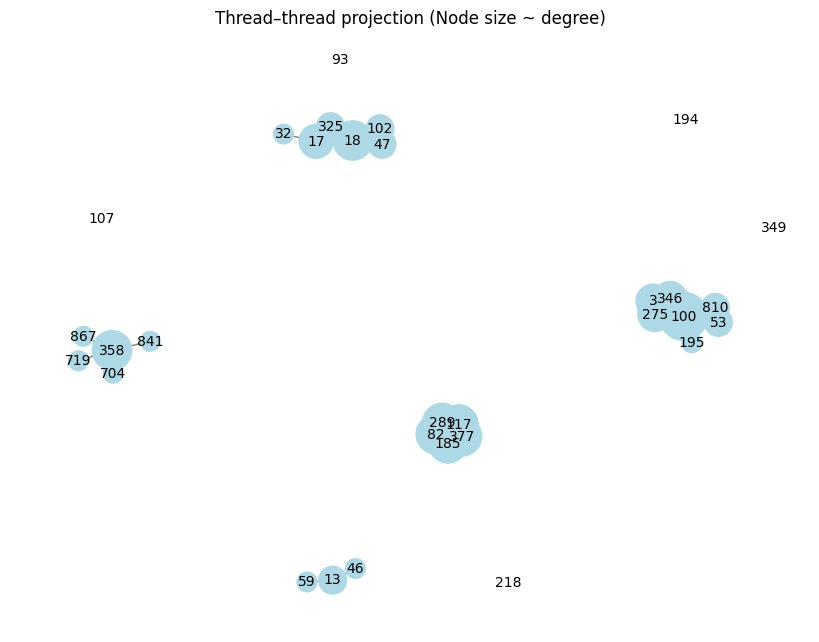

In [19]:
# Thread-thread plot layout
plt.figure(figsize=(8,6))

# Node size proportional to degree
degree_dict = dict(thread_proj_trimmed.degree())
node_sizes = [degree_dict[n]*200 for n in thread_proj_trimmed.nodes()]  # scale factor for visibility

# Use spring layout for better spacing
pos = nx.spring_layout(thread_proj_trimmed, seed=42)

# Draw network
nx.draw(
    thread_proj_trimmed,
    pos,
    with_labels=True,
    node_color="lightblue",
    edge_color="gray",
    node_size=node_sizes,
    font_size=10
)

plt.title("Thread–thread projection (Node size ~ degree)")
plt.show()


#Inferences

(1) Relationships Among Users:

Users 704, 719, 841, 867, and 358 are tightly connected and frequently post in the same threads. They form a major cluster, representing shared interests and consistent interactions. Users 100, 810, and 53 form a smaller cluster with fewer connections. User 810 acts as a bridge between the two clusters, helping information flow across communities. Overall, the user network shows how active participants are grouped and how some users connect different groups.

(2) Relationships Among Threads:

Thread 100 has the highest degree and is connected to many other threads. Threads 18, 117, 289, 82, 377, 185, and 358 form smaller groups of related topics. Community 1 (346, 53, 275, 3, 100, 810, 195) and Community 2 (32, 47, 102, 17, 18, 325) show threads that share many users. Threads 100 and 810 have higher betweenness and act as bridges between groups. Overall, the thread network shows which topics are linked and which threads connect different discussions.

#Conclusion

The two-mode network analysis of the Facebook-like forum data shows clear interaction patterns between users and threads.
The projection onto the user network identifies active users and cohesive subgroups, while the thread projection highlights which discussions attract shared participants.
After applying the island method, the reduced network focuses on the strongest relationships, simplifying the structure and emphasizing the core of community activity.
Overall, this dataset demonstrates how bipartite network analysis can help reveal both social clusters and topic interconnections within online communication systems.

In [9]:
!jupyter nbconvert --to pdf Data620_Project02.ipynb

[NbConvertApp] Converting notebook Data620_Project02.ipynb to pdf
[NbConvertApp] Support files will be in Data620_Project02_files\
[NbConvertApp] Making directory .\Data620_Project02_files
[NbConvertApp] Writing 67257 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | b had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 294178 bytes to Data620_Project02.pdf
